# Importing the Libraries

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score


# Loading Data

In [141]:
df = pd.read_csv(r"C:\Users\k\Documents\NEXTGEN 3MTT\loan_pipeline\Loan_Dataset.csv")

# Reading the first five Rows

In [142]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Removing Loan_ID

In [8]:
df.drop('Loan_ID', axis = 1, inplace = True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Checking the Information of the Data

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


# Statistics of the Data

In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
df.describe(include = 'all')

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


# Checking the shape of the data

In [12]:
df.shape

(614, 12)

# DATA CLEANING

# Checking for Duplicate

In [13]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
609    False
610    False
611    False
612    False
613    False
Length: 614, dtype: bool

In [14]:
# or

In [15]:
df.duplicated().sum()

0

# To print the duplicated rows

In [16]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Loan_Status]
Index: []


In [17]:
# Or

In [18]:
df[df.duplicated()]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


# Removing Duplicates

In [19]:
#df.drop_duplicates(inplace=True)

Or create a new DataFrame:

#df = df.drop_duplicates()


Check Dataset Shape Before and After Removing Duplicates

#print("Before:", df.shape)

#df = df.drop_duplicates()

#print("After:", df.shape)
This helps to verify how many duplicate rows were removed.

SyntaxError: invalid syntax (3741797753.py, line 3)

# checking data types

In [21]:
df.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

# Checking for Missing Values

In [22]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Filling Missing Values in Numeric Columns

In [23]:
df.fillna(df.median(numeric_only = True), inplace = True)

In [24]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

# Filling Missing Values in Categorical Columns

In [25]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\k\AppData\Local\Temp\ipykernel_5688\3448830320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [26]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Encoding Categorical Variables

In [27]:
Cat_Var = df.select_dtypes(include = 'object').columns
for col in Cat_Var:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Defining Features and Target Variables

In [28]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [29]:
df['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

# Spliting the Data into Training and Testing Sets (80% Training, and 20% Testing)

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [31]:
X_train

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
83,1,1,0,0,0,6000,2250.0,265.0,360.0,1.0,1
90,1,1,0,0,0,2958,2900.0,131.0,360.0,1.0,1
227,1,1,2,0,0,6250,1695.0,210.0,360.0,1.0,1
482,1,1,0,0,0,2083,3150.0,128.0,360.0,1.0,1
464,1,0,0,0,0,4166,0.0,98.0,360.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
71,1,1,2,1,1,1875,1875.0,97.0,360.0,1.0,1
106,1,1,2,0,0,11417,1126.0,225.0,360.0,1.0,2
270,0,0,0,0,0,3237,0.0,30.0,360.0,1.0,2
435,0,1,0,0,0,10047,0.0,128.0,240.0,1.0,1


In [32]:
y_train

83     0
90     1
227    1
482    1
464    0
      ..
71     1
106    1
270    1
435    1
102    1
Name: Loan_Status, Length: 491, dtype: int32

In [33]:
print('shape of x_train:', X_train.shape)
print('shape of x_test:', X_test.shape)
print('shape of y_train:', y_train.shape)
print('shape of y_test:', y_test.shape)

shape of x_train: (491, 11)
shape of x_test: (123, 11)
shape of y_train: (491,)
shape of y_test: (123,)


# Scale Features

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


# LogisticRegression()

In [36]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Evaluation

In [37]:
Accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic_Regression_Accuracy: {Accuracy_log_reg:.2f}")
print(classification_report(y_test, y_pred_log_reg))
print(confusion_matrix(y_test, y_pred_log_reg))

Logistic_Regression_Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

[[18 25]
 [ 1 79]]


In [38]:
confusion = confusion_matrix(y_test, y_pred_log_reg)

<Axes: >

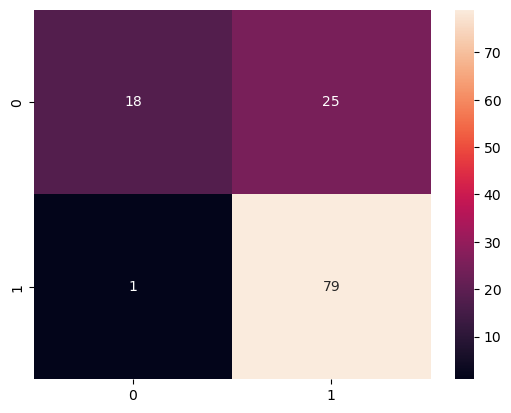

In [39]:
sns.heatmap(confusion, annot = True, fmt = 'd')

# RandomForestClassifier

In [40]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [41]:
Accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"RandomForestClassifier: {Accuracy_rf:.2f}")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

RandomForestClassifier: 0.75
              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75      0.93      0.83        80

    accuracy                           0.75       123
   macro avg       0.75      0.67      0.68       123
weighted avg       0.75      0.75      0.73       123

[[18 25]
 [ 6 74]]


In [42]:
confusion = confusion_matrix(y_test, y_pred_rf)

<Axes: >

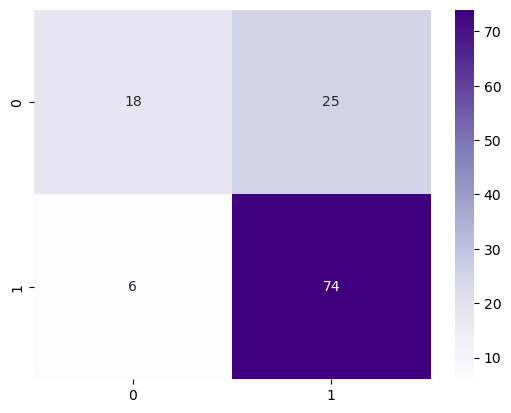

In [43]:
sns.heatmap(confusion, annot = True, fmt = 'd', cmap = 'Purples' )

# Decision Tree

In [143]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=42)
dtc.fit(X_train_scaled, y_train)
y_pred_dtc = dtc.predict(X_test_scaled)

In [144]:
Accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"Decision Tree: {Accuracy_dtc:.2f}")
print(classification_report(y_test, y_pred_dtc))
print(confusion_matrix(y_test, y_pred_dtc))

Decision Tree: 0.77
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123

[[18 25]
 [ 3 77]]


<Axes: >

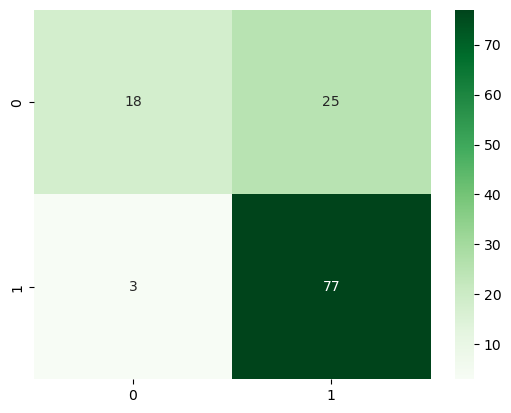

In [145]:
confusion = confusion_matrix(y_test, y_pred_dtc)
sns.heatmap(confusion, annot = True, fmt = 'd', cmap = 'Greens')

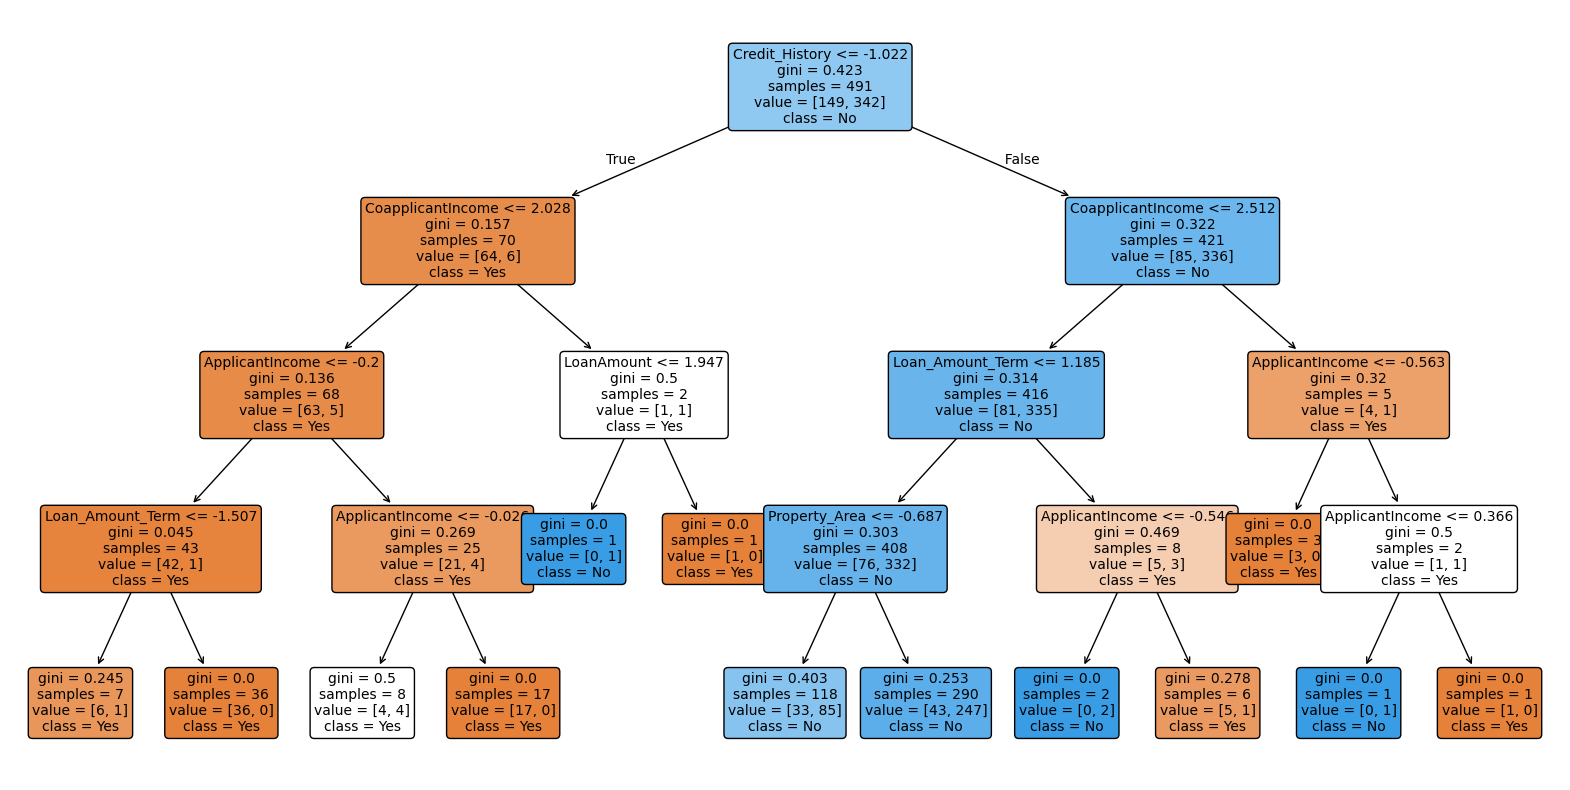

In [146]:
plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X.columns, class_names=['Yes', 'No'], filled=True, rounded=True, fontsize=10)
plt.show()

# K-Nearest Neighbours (KNN) Model

In [52]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [53]:
Accuracy_knn = accuracy_score(y_test, y_pred_knn)

In [54]:
print(f"Accuracy_knn:, {Accuracy_knn:.2f}")
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

Accuracy_knn:, 0.76
              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123

[[17 26]
 [ 4 76]]


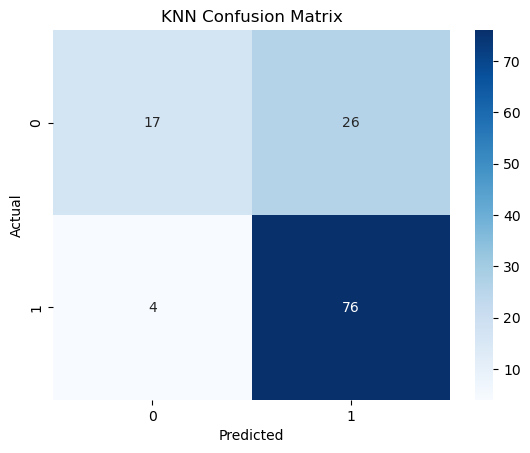

In [55]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot = True, fmt = 'd', cmap ='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Summary

In [90]:
print(f"Logistic_Regression_Accuracy: {Accuracy_log_reg: .2f}")
print(f"RandomForestClassifier: {Accuracy_rf:.2}")
print(f"Decision Tree: {Accuracy_dtc:.2}")
print(f"Accuracy_knn:, {Accuracy_knn:.2}")

Logistic_Regression_Accuracy:  0.79
RandomForestClassifier: 0.75
Decision Tree: 0.77
Accuracy_knn:, 0.76


# Features Importance
In LogisticRegression, we use "Coefficient". Example is "Coefficient": log_reg.coef_[0]})

but for tree-based models such as:
Decision Tree
Random Forest
XGBoost
we use feature_importances_

In [57]:
# Features Importance for LogisticRegression

In [58]:
feature_importance = pd.DataFrame({"Feature": X.columns, "Coefficient": log_reg.coef_[0]})

feature_importance.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
9,Credit_History,1.310881
1,Married,0.313116
2,Dependents,0.117930
10,Property_Area,0.077321
4,Self_Employed,0.049921
8,Loan_Amount_Term,0.045014
5,ApplicantIncome,-0.027031
0,Gender,-0.067811
6,CoapplicantIncome,-0.152199
3,Education,-0.159361


In [59]:
feature_importance = pd.DataFrame({"Feature": X.columns,"Coefficient": log_reg.coef_[0]})
feature_importance["Absolute_Coefficient"] = (feature_importance["Coefficient"].abs())
feature_importance.sort_values(by="Absolute_Coefficient", ascending=False)

,Feature,Coefficient,Absolute_Coefficient
9,Credit_History,1.310881,1.310881
1,Married,0.313116,0.313116
7,LoanAmount,-0.176504,0.176504
3,Education,-0.159361,0.159361
6,CoapplicantIncome,-0.152199,0.152199
2,Dependents,0.117930,0.117930
10,Property_Area,0.077321,0.077321
0,Gender,-0.067811,0.067811
4,Self_Employed,0.049921,0.049921
8,Loan_Amount_Term,0.045014,0.045014


In [60]:
# Features Importance for Decision Tree

In [147]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': dtc.feature_importances_})
feature_importance.sort_values(by = 'Importance', ascending = False)

,Feature,Importance
9,Credit_History,0.767285
5,ApplicantIncome,0.088096
6,CoapplicantIncome,0.054498
8,Loan_Amount_Term,0.041055
10,Property_Area,0.036470
7,LoanAmount,0.012595
0,Gender,0.000000
1,Married,0.000000
2,Dependents,0.000000
3,Education,0.000000


In [62]:
# Features Importance for Random Forest (rf)

In [63]:
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_})
feature_importance.sort_values(by = "Importance", ascending = False)

,Feature,Importance
9,Credit_History,0.262914
5,ApplicantIncome,0.202666
7,LoanAmount,0.185022
6,CoapplicantIncome,0.113861
8,Loan_Amount_Term,0.051443
10,Property_Area,0.049602
2,Dependents,0.048141
1,Married,0.023648
3,Education,0.021271
0,Gender,0.020718


In [64]:
# Features Importance for KNN

In [65]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(knn, X_test_scaled,y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': result.importances_mean})

importance_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
9,Credit_History,0.176423
6,CoapplicantIncome,0.018699
5,ApplicantIncome,0.014634
8,Loan_Amount_Term,0.008943
7,LoanAmount,0.006504
10,Property_Area,-0.001626
1,Married,-0.005691
2,Dependents,-0.007317
3,Education,-0.008943
4,Self_Employed,-0.012195


# Retrain Final Model Using RandomForestClassifier

In [67]:
Top_features = ['Credit_History', 'ApplicantIncome', 'LoanAmount', 'CoapplicantIncome', 'Loan_Amount_Term' ]
X_selected = df[Top_features]

In [77]:
X_selected

,Credit_History,ApplicantIncome,LoanAmount,CoapplicantIncome,Loan_Amount_Term
0,1.0,5849,128.0,0.0,360.0
1,1.0,4583,128.0,1508.0,360.0
2,1.0,3000,66.0,0.0,360.0
3,1.0,2583,120.0,2358.0,360.0
4,1.0,6000,141.0,0.0,360.0
...,...,...,...,...,...
609,1.0,2900,71.0,0.0,360.0
610,1.0,4106,40.0,0.0,180.0
611,1.0,8072,253.0,240.0,360.0
612,1.0,7583,187.0,0.0,360.0


# Split the Data Again

In [78]:
X_selected_train, X_selected_test, y_selected_train, y_selected_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Scale the Features again

In [79]:
scaler = StandardScaler()
X_selected_train_scaled = scaler.fit_transform(X_selected_train)
X_selected_train_scaled = scaler.transform(X_selected_test)

#  LogisticRegression (Retrained)

In [84]:
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_selected_train_scaled, y_selected_train)
y_selected_pred_lr = final_model.predict(X_selected_test_scaled)

In [98]:
accuracy_final = accuracy_score(y_selected_test, y_selected_pred_lr)
print(f"Retrained Model Accuracy: {accuracy_final:.2f}")

Retrained Model Accuracy: 0.79


# DecisionTreeClassifier (Trained)

In [117]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=42)
dtc.fit(X_selected_train_scaled, y_selected_train)
y_selected_pred_dtc = dtc.predict(X_selected_test_scaled)

In [118]:
accuracy_dtc2 = accuracy_score(y_selected_test, y_selected_pred_dtc)
print(f"Retrained Model Accuracy: {accuracy_dtc2:.2f}")

Retrained Model Accuracy: 0.77


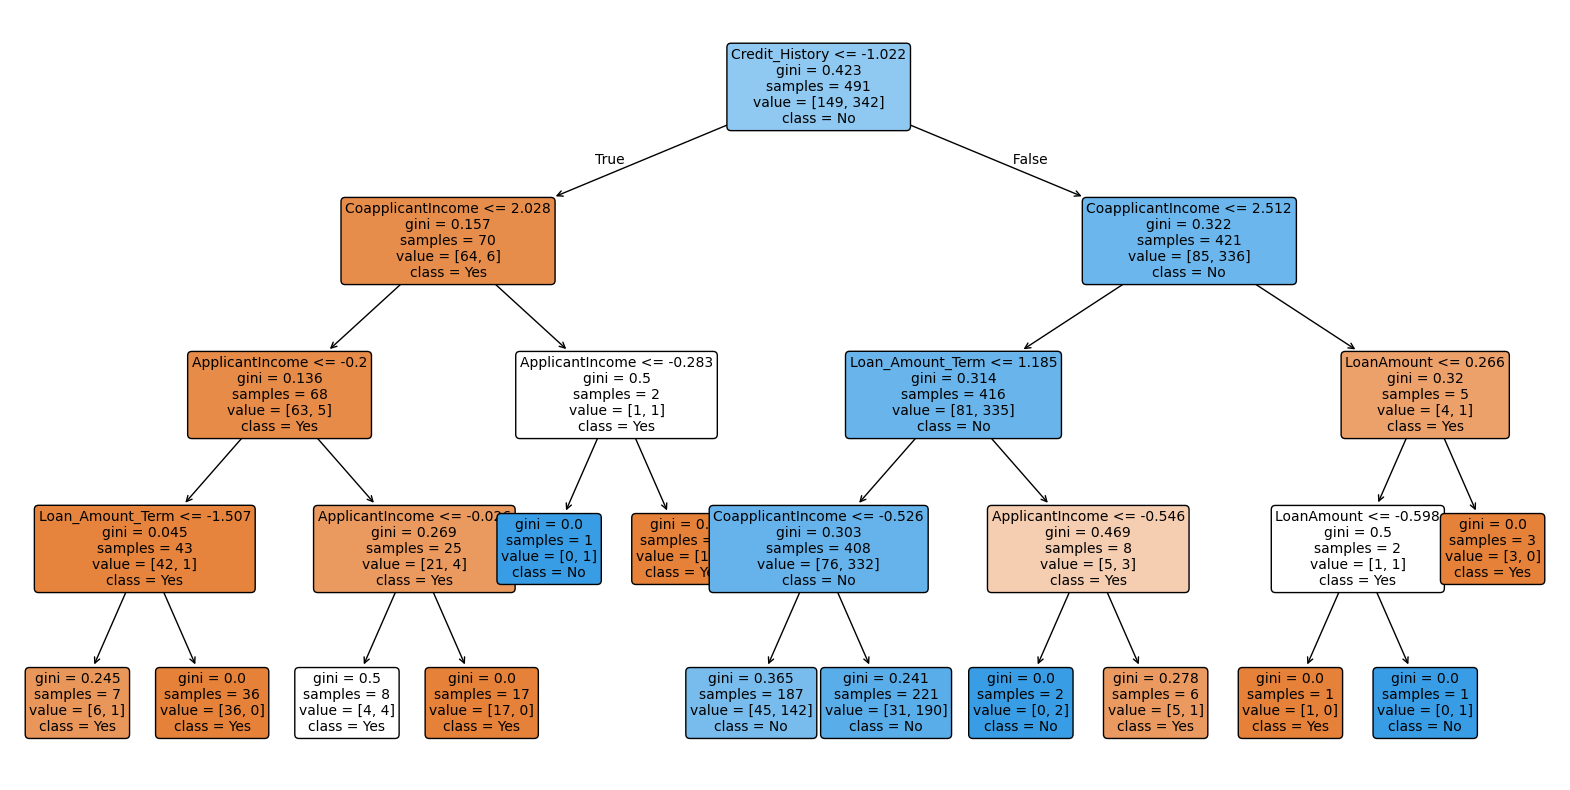

In [119]:
plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X_selected.columns, class_names=['Yes', 'No'], filled=True, rounded=True, fontsize=10)
plt.show()

# KNeighborsClassifier (Retrained)

In [108]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_selected_train_scaled, y_selected_train)
y_selected_pred_knn = knn.predict(X_selected_test_scaled)

In [110]:
accuracy_knn2 = accuracy_score(y_selected_test, y_selected_pred_knn)
print(f"Retrained Model Accuracy: {accuracy_knn2:.2f}")

Retrained Model Accuracy: 0.77


# RandomForestClassifier (Retrained)

In [160]:
New_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
New_model.fit(X_selected_train_scaled, y_selected_train)
y_selected_pred_rf_final = New_model.predict(X_selected_test_scaled)

accuracy_rf2 = accuracy_score(y_selected_test, y_selected_pred_rf_final)
print(f"Retrained Model Accuracy: {accuracy_rf2:.2f}")
print(classification_report(y_selected_test, y_selected_pred_rf_final))
print(confusion_matrix(y_selected_test, y_selected_pred_rf_final))

Retrained Model Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.74      0.47      0.57        43
           1       0.76      0.91      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.69      0.70       123
weighted avg       0.75      0.76      0.74       123

[[20 23]
 [ 7 73]]


# Saving the Model

In [164]:
import joblib
joblib.dump(New_model, "Loan_model.pkl")


['Loan_model.pkl']

In [165]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

# Loading the Model

In [162]:
Final_model = joblib.load("Loan_model.pkl")

print(Final_model)


RandomForestClassifier(random_state=42)


In [167]:
print(X_selected_train.columns)

Index(['Credit_History', 'ApplicantIncome', 'LoanAmount', 'CoapplicantIncome',
       'Loan_Amount_Term'],
      dtype='object')
